# Day 4 — Exploratory Data Analysis
### Project: Predict Disney+ content rating from genre, runtime, release year, and country

**What I'm predicting:** the content rating (TV-G, PG, TV-14, etc.) of a Disney+ title, based on its genre tags, runtime, release year, and country of origin — a 9-class classification problem with real class imbalance.

**Why it's useful:** streaming platforms need consistent content ratings for parental controls and catalog search, but ratings are sometimes missing or inconsistent when new titles are ingested. A model that predicts a likely rating from genre and runtime could flag mis-tagged titles for review.

This notebook loads the **cleaned** dataset from Stage 01 (`disney_plus_titles_clean.csv`) — not the raw file — and explores it enough that someone unfamiliar with the data could understand it from this notebook alone.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# --- CONFIGURATION: set this once for your machine ---
# Same approach as learn_ml.ipynb / clean_data.ipynb: cwd and VS Code
# internals both proved unreliable in this environment, so this is a
# single explicit path. Update this if you ever move the repo.
REPO_ROOT = Path("C:\\Users\\Julianna\\SLU\\Internship\\nlp-text-classifier-pipeline")
CLEAN_PATH = REPO_ROOT / "stage01" / "disney_plus_titles_clean.csv"

df = pd.read_csv(CLEAN_PATH)
# genre_list round-trips through CSV as a string repr of a list -- parse it back
df["genre_list"] = df["genre_list"].apply(ast.literal_eval)

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Shape: 1447 rows, 15 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,genre_list
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",Unknown,2021-11-26,2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!,23,min,"[Animation, Family]"
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",Unknown,2021-11-26,1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...,91,min,[Comedy]
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,2021-11-26,2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.,23,min,"[Animation, Comedy, Family]"


## Summary statistics

Numeric columns first, then a look at the categorical target.

In [2]:
df[["release_year", "duration_value"]].describe()

,release_year,duration_value
count,1447.000000,1447.000000
mean,2003.055978,52.825155
std,21.868658,46.566218
min,1928.000000,1.000000
25%,1999.000000,4.000000
50%,2011.000000,46.000000
75%,2018.000000,93.000000
max,2021.000000,183.000000


In [3]:
df["rating"].value_counts()

rating
TV-G        318
TV-PG       301
G           253
PG          236
TV-Y7       131
TV-14        79
PG-13        66
TV-Y         50
TV-Y7-FV     13
Name: count, dtype: int64

## Chart 1 — Class distribution (the prediction target)

This is the single most important chart in this notebook, and it comes first on purpose: before looking at *any* feature, we need to know how imbalanced the target is, because that shapes which evaluation metric is valid later.

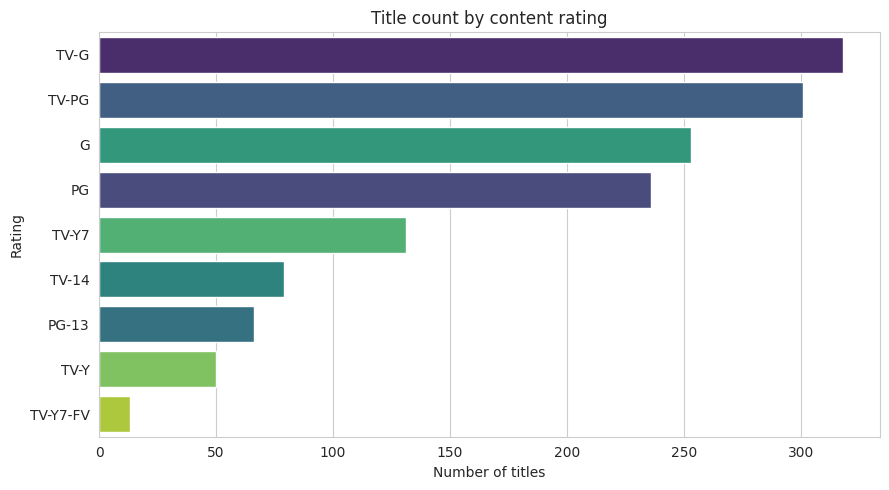

In [4]:
order = df["rating"].value_counts().index
plt.figure(figsize=(9, 5))
sns.countplot(data=df, y="rating", order=order, hue="rating", palette="viridis", legend=False)
plt.title("Title count by content rating")
plt.xlabel("Number of titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

**Observation:** TV-G (318) and TV-PG (301) are the largest classes; TV-Y7-FV has only 13 titles — a ~24x gap between the largest and smallest class. A model that always predicts "TV-G" would score roughly 22% accuracy just by guessing the mode, which sounds bad but isn't a fair floor either, since some classes are nearly unreachable with this little data. **Implication:** raw accuracy is not a trustworthy metric here — per-class precision/recall or a balanced accuracy score is needed once modeling starts.

## Chart 2 — Movie vs. TV Show composition

Context for the catalog before looking at how rating relates to anything else.

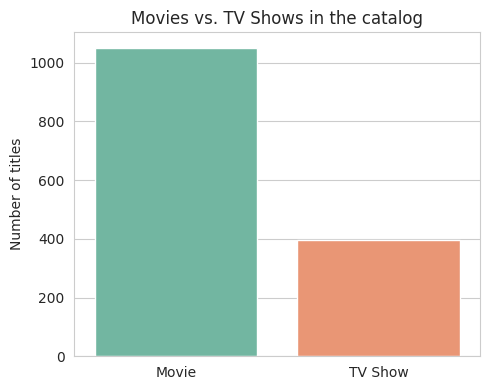

type
Movie      72.6
TV Show    27.4
Name: proportion, dtype: float64 %


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="type", hue="type", palette="Set2", legend=False)
plt.title("Movies vs. TV Shows in the catalog")
plt.xlabel("")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

print(df["type"].value_counts(normalize=True).round(3) * 100, "%")

**Observation:** ~72% of the catalog is Movies, ~28% is TV Shows. Not the prediction target, but relevant context: TV Shows are a minority of titles, so any genre or rating pattern that's specific to TV content will naturally have less data behind it.

## Chart 3 — Release year distribution, split by type

Day 2's groupby already hinted at this (Movies averaged release year 1999, TV Shows 2013) — this chart shows the *shape* of that difference, not just the average.

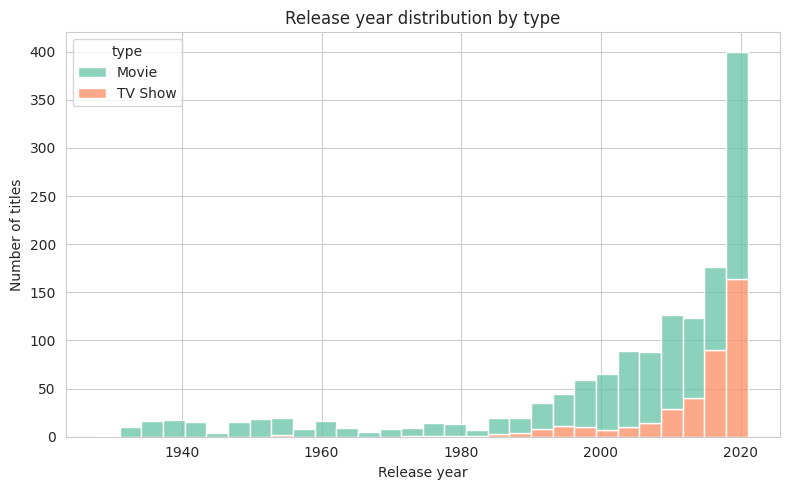

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="release_year", hue="type", multiple="stack", bins=30, palette="Set2")
plt.title("Release year distribution by type")
plt.xlabel("Release year")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

**Observation:** Movies spread across a much wider range, including decades-old catalog titles, while TV Shows cluster heavily in the last ~10 years. A plausible explanation (not confirmed by this data alone) is that Disney+'s movie catalog draws on a large back-library, while its TV Show catalog leans on recent or original productions — worth stating as a hypothesis, not a fact, in the Friday demo.

## Chart 4 — Duration distribution, split by unit

`duration` mixes two different measurements depending on `type` (minutes for Movies, seasons for TV Shows) — Stage 01 split these into `duration_value` + `duration_unit`. They can't be plotted on one shared axis, so here they're shown side by side.

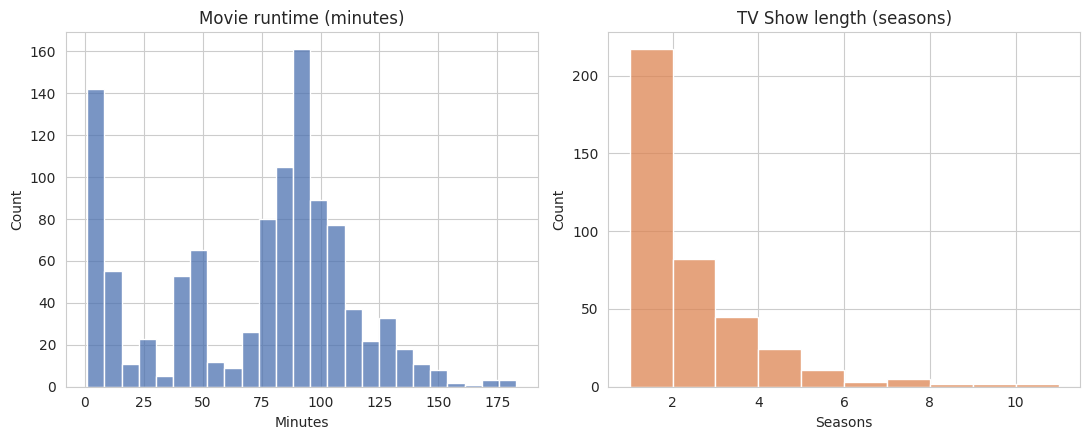

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df[df["duration_unit"] == "min"]["duration_value"], bins=25, ax=axes[0], color="#4C72B0")
axes[0].set_title("Movie runtime (minutes)")
axes[0].set_xlabel("Minutes")

sns.histplot(df[df["duration_unit"] == "Season"]["duration_value"], bins=range(1, 12), ax=axes[1], color="#DD8452")
axes[1].set_title("TV Show length (seasons)")
axes[1].set_xlabel("Seasons")

plt.tight_layout()
plt.show()

**Observation:** movie runtimes cluster between roughly 40-100 minutes with a long tail; the vast majority of TV Shows have just 1 season, with a sharp drop-off after that. **Caution carried over from Stage 01:** `duration_unit` perfectly predicts `type` (every Movie is "min", every TV Show is "Season") — that's a leakage risk *if* a future version of this project targets `type` instead of `rating`. It's not a problem for the current target, but it's the reason `duration` needs to stay in mind as "type in disguise," not a neutral numeric feature.

## Chart 5 — Top genres by frequency

`listed_in` was split into `genre_list` in Stage 01 since one title can carry multiple genres. Exploding it counts each genre tag once per title.

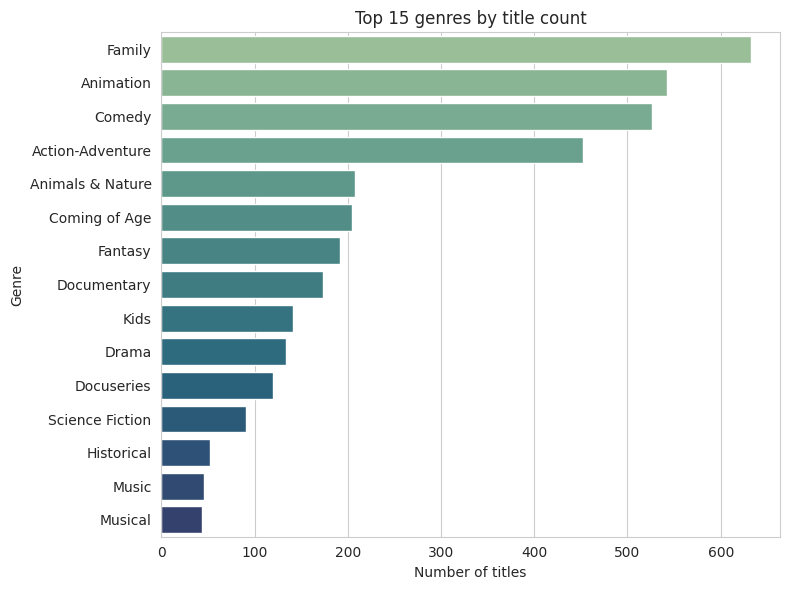

In [8]:
genre_counts = df.explode("genre_list")["genre_list"].value_counts().head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette="crest", legend=False)
plt.title("Top 15 genres by title count")
plt.xlabel("Number of titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Observation:** Family (632), Animation (542), and Comedy (526) dominate — consistent with Disney+'s brand. The top genres appear on far more than 1,447 titles combined, confirming most titles carry multiple genre tags. **Implication for modeling:** with dozens of distinct genre tags but a long tail of rare ones, one-hot encoding every genre would create a lot of near-empty columns — worth capping at the top N genres (e.g. top 15) and bucketing the rest as "Other" when this becomes model input.

## Chart 6 — Rating distribution across top genres

This is the closest thing to a "correlation" chart available with mostly categorical data: for each of the top genres, what share of titles falls into each rating?

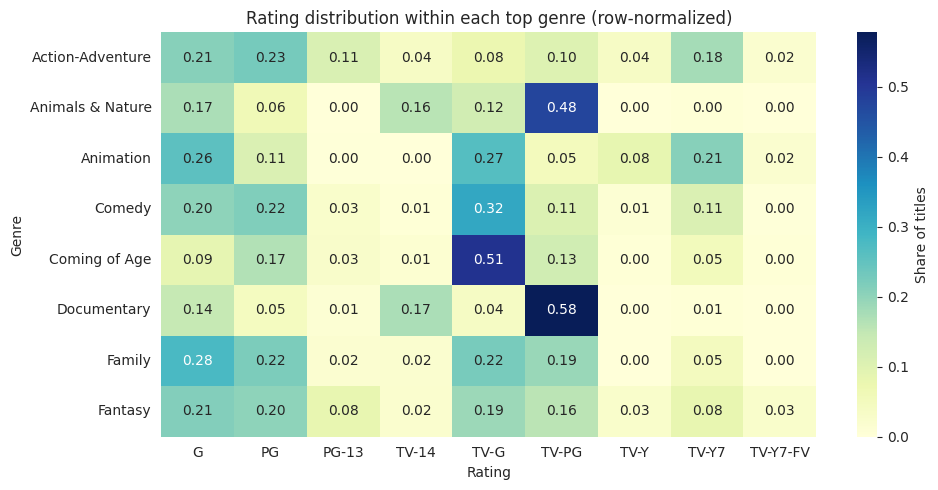

In [9]:
top_genres = genre_counts.head(8).index.tolist()
exploded = df.explode("genre_list")
subset = exploded[exploded["genre_list"].isin(top_genres)].reset_index(drop=True)

cross = pd.crosstab(subset["genre_list"], subset["rating"], normalize="index")

plt.figure(figsize=(10, 5))
sns.heatmap(cross, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label": "Share of titles"})
plt.title("Rating distribution within each top genre (row-normalized)")
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

**Observation:** this is the chart that actually justifies the project. Genres skew toward different ratings rather than spreading evenly. Kid-facing genres cluster toward G/TV-G — Coming of Age is 51% TV-G, Animation is 53% G+TV-G (plus another 21% TV-Y7), Family splits fairly evenly across G/PG/TV-G. Documentary and Animals & Nature both lean heavily toward **TV-PG** (58% and 48% respectively) rather than a stricter or more mature rating — worth noting since "documentary" might sound like mature content but isn't rated that way here. Action-Adventure is the one genre with no dominant peak — spread fairly evenly across G, PG, and TV-Y7 — which is itself useful to know: not every genre carries equally strong signal for a model. That's real, non-obvious signal a model could learn from — unlike the `duration`/`type` relationship, this correlation is imperfect and informative rather than a leakage red flag.

## Chart 7 — Country representation

A quick check on whether `country` is likely to be a useful feature at all.

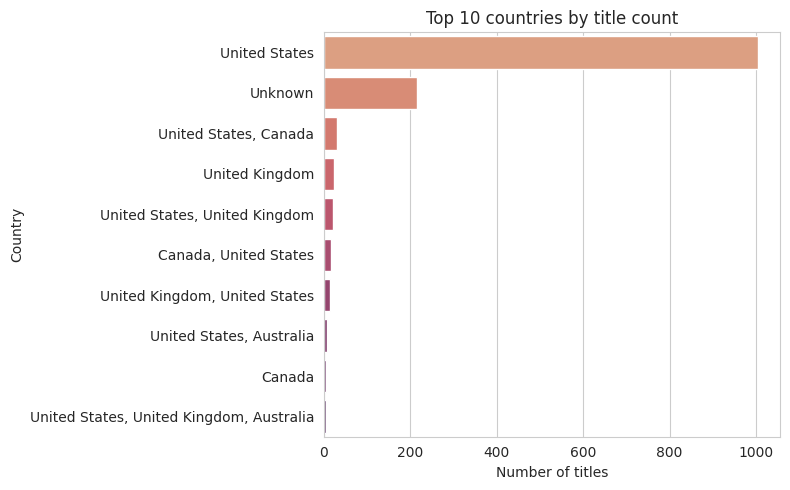

'Unknown' share: 14.9%


In [10]:
country_counts = df["country"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette="flare", legend=False)
plt.title("Top 10 countries by title count")
plt.xlabel("Number of titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print(f"'Unknown' share: {(df['country'] == 'Unknown').mean():.1%}")

**Observation:** United States dominates the catalog, and "Unknown" (the 219 rows Stage 01 filled rather than dropped) is itself one of the largest categories. With one category this dominant and another this large just meaning "we don't know," `country` may contribute little real signal once modeling starts — worth testing with and without it rather than assuming it helps.

## Summary of findings

1. **The rating target is meaningfully imbalanced** (~24x gap between largest and smallest class) — evaluation must use per-class or balanced metrics, not raw accuracy.
2. **Genre is the strongest signal found so far** — rating distributions differ clearly by genre (Chart 6), which directly supports the project's premise that genre/runtime can predict rating.
3. **`duration` is entangled with `type`, not just `rating`** — a real relationship worth using, but one that needs care so it isn't mistaken for a stronger signal than it is if the target ever changes.

## Open questions

- Dataset license is still unconfirmed (flagged in Stage 01's `workflow.md`) — needs resolving before any public presentation of this work.
- Is `country` worth keeping as a feature given how dominant "Unknown" and "United States" are, or should it be dropped for the first model?
- How many genres should be kept as individual one-hot columns vs. bucketed into "Other" before this becomes model input in Stage 02?
- Should TV-Y7-FV (13 titles) be merged into TV-Y7, or kept separate despite having almost no data to learn from?